#### 🌟 **1. What is Polynomial Regression? (Super Easy Explanation)**

**Polynomial Regression** is just a **modified Linear Regression**.

But instead of fitting a **straight line**, it fits a **curved line**.

##### 👉 Linear Regression

Predicts using:
[
y = b_0 + b_1x
]
(Straight line)

##### 👉 Polynomial Regression

Predicts using:
[
y = b_0 + b_1x + b_2x^2 + b_3x^3 + \dots
]
(Curve)

---

#### 🎯 **2. Why do we need Polynomial Regression?**

Sometimes **data is NOT linear**.

Examples:

* Experience vs Salary (fast growth → slow growth)
* Age vs Height of children
* Engine size vs Mileage
* Marketing Spend vs Sales

These relationships are **curved**, not straight.

##### ❌ Linear Regression fails

Because the line cannot follow the curve.

##### ✔ Polynomial Regression fits perfectly

Because it bends according to the data.

---

#### 🎨 **3. Visual Example**

##### Linear Regression tries to fit:

```
-----------
         ------
```

##### Polynomial Regression fits like:

```
    /\
  /    \
 /      \
```

A smooth curve!

---


In [54]:
import pandas as pd

data = {
    'Experience': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Salary':     [15, 20, 28, 40, 55, 70, 90, 115, 150, 190]
}

df = pd.DataFrame(data)
df


,Experience,Salary
0,1,15
1,2,20
2,3,28
3,4,40
4,5,55
5,6,70
6,7,90
7,8,115
8,9,150
9,10,190


Why this dataset?

✔ Salary grows slow at first

✔ Then grows fast → Non-linear

✔ Perfect for polynomial regression

In [55]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import warnings 
warnings.filterwarnings('ignore')

# Selecting X(independent) and y(dependent) columns
X = df[['Experience']]
y = df['Salary']

# Create Polynomial Features with degree = 2 (quadratic)
poly = PolynomialFeatures(degree = 2)
X_poly = poly.fit_transform(X)

X_poly


array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   4.,  16.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.]])

It means :

| X | X² |
| - | -- |
| 1 | 1  |
| 2 | 4  |
| 3 | 9  |


In [56]:
# Fit the Model
model = LinearRegression()
model.fit(X_poly, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
# Check score on  data
model.score(X_poly, y)  # Returns R2_score on training data

0.9973828089647816

In [58]:
# Model slope and intercept
print(model.coef_)
print(model.intercept_)

[ 0.         -3.6780303   2.03409091]
19.216666666666626


This means: <br/>
y= 0 + (-3.6780303 * X) + (2.03409091 * X)

##### **Polynomial Regression coefficients correspond to:** <br/>
coef_[0] → coefficient for bias term (ignore this)

coef_[1] → coefficient for X

coef_[2] → coefficient for X²

(If degree = 3, then you will get): 

coef_[1] → X

coef_[2] → X²

coef_[3] → X³



In [59]:
# Manual Prediction 

y_manual = 19.216666666666626 + (-3.6780303 * 6) + (2.03409091*(6**2))
print("Manual Prediction:", y_manual)


Manual Prediction: 70.37575762666663


In [60]:
model.predict([[1, 6, 6 ** 2]])

array([70.37575758])

Here, the model expects 3 features:

[1, X, X²]

But you are giving only:

[6]

The error says: X has 1 feature, but model is expecting 3 features.


✅ Correct Way to Predict in Polynomial Regression

You must transform your input using poly.transform before prediction.


In [61]:
model.predict(poly.transform([[6]]))

array([70.37575758])

🔥 Why polynomial.transform is required?

Because your model was trained on: 


array([[  1.,   1.,   1.], <br/>
       [  1.,   2.,   4.], <br/>
       [  1.,   3.,   9.], <br/>
       [  1.,   4.,  16.], <br/>
       [  1.,   5.,  25.], <br/>
       [  1.,   6.,  36.], <br/>
       [  1.,   7.,  49.], <br/>
       [  1.,   8.,  64.], <br/>
       [  1.,   9.,  81.], <br/>
       [  1.,  10., 100.]])

So at prediction time, the model needs:

[1 , 6 , 6²]  → [1 , 6 , 36]

Only poly.transform can generate these correct features.



In [62]:
# predicting X data  from model 
y_pred = model.predict(X_poly) # Data leakage

In [63]:
# Checking model performance/ model evaluation / Performace Metrices
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

print(f'R2_score : {r2_score(y, y_pred)}')
print(f'MSE : {mean_squared_error(y, y_pred)}')
print(f'RMSE : {np.sqrt(mean_squared_error(y, y_pred))}')
print(f'MAE : {mean_absolute_error(y, y_pred)}')
print(f'MAE_Percentage : {mean_absolute_percentage_error(y, y_pred)}')

R2_score : 0.9973828089647816
MSE : 8.141060606060613
RMSE : 2.853254388599203
MAE : 2.387878787878793
MAE_Percentage : 0.047097820781142115


Note : This good performance of model is due to Data leakage

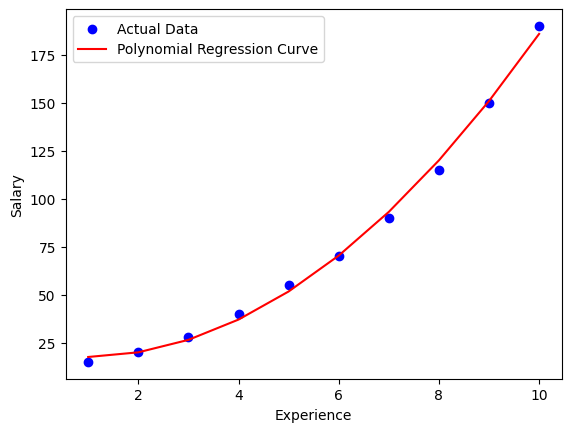

In [64]:
# Visualization (Graph): 

plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Polynomial Regression Curve')
plt.legend()
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()


🎉How Polynomial Regression works? (Simple Logic)

Polynomial Regression:

Expands your features (x → x² → x³)

Fits Linear Regression on these new features

Result becomes curved instead of straight

Important thing:

📌 It is still Linear Regression in mathematics
(because coefficients remain linear)

Only input variables become non-linear.

🔥What is Degree? (Very Important)
Degree = how much curve you want

| Degree | Shape                |
| ------ | -------------------- |
| 1      | Straight line        |
| 2      | U-shape curve        |
| 3      | S-shape curve        |
| 4+     | More flexible curves |


Too low degree → underfitting

Too high degree → overfitting

(Your curve bends too much)


---

#### ⭐ **What is Polynomial Regression? (Easy Explanation)**

Polynomial Regression is a type of **Linear Regression**, but instead of fitting a straight line, it fits a **curve**.

👉 **Use it when the relationship between X and Y is not straight (non-linear).**

Example:

* Temperature vs Ice-cream sales
* Experience vs Salary
* Age vs Height growth
* Years vs Car price (price drops faster after a point)

If data looks like a **curve**, not a line → use Polynomial Regression.

---

#### ⭐ **Why Linear Regression Fails**

Imagine data like this:

```
     *
   *   *
 *       *
*          *
```

A straight line can’t fit this.
Polynomial regression draws a **curved line** that fits the data better.

---

#### ⭐ **How Polynomial Regression Works (Super Simple)**

We convert the original feature `X` into **polynomial features**:

Example:
If X = 3, we create:

* X¹ = 3
* X² = 9
* X³ = 27

So the model becomes:

[
y = b_0 + b_1X + b_2X^2 + b_3X^3
]

This gives the model the power to bend.

---

#### ⭐ Dataset Example: **Experience vs Salary**

| Experience (Years) | Salary (₹ lakhs) |
| ------------------ | ---------------- |
| 1                  | 2                |
| 2                  | 2.8              |
| 3                  | 3.6              |
| 4                  | 5                |
| 5                  | 7.5              |
| 6                  | 11               |
| 7                  | 15               |

This curve goes **slow → medium → fast**, so it's not linear.

---

#### ⭐ **Step-by-Step Polynomial Regression in Python**



In [65]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Step 2: Create Dataset
X = np.array([1,2,3,4,5,6,7]).reshape(-1,1)   # Features
y = np.array([2,2.8,3.6,5,7.5,11,15])         # Labels


# Step 3: Convert X into Polynomial Features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_poly

array([[ 1.,  1.,  1.],
       [ 1.,  2.,  4.],
       [ 1.,  3.,  9.],
       [ 1.,  4., 16.],
       [ 1.,  5., 25.],
       [ 1.,  6., 36.],
       [ 1.,  7., 49.]])

Now X_poly becomes: 
    
| X⁰  | X¹  | X²  |
| --- | --- | --- |
| 1   | 1   | 1   |
| 1   | 2   | 4   |
| 1   | 3   | 9   |
| 1   | 4   | 16  |
| 1   | 5   | 25  |
| ... | ... | ... |


In [66]:
# Step 4: Train Model
model = LinearRegression()
model.fit(X_poly, y)

# Step 5: Make Predictions
model.predict(poly.transform([[5]]))


array([7.68571429])

In [67]:
y_pred = model.predict(X_poly)

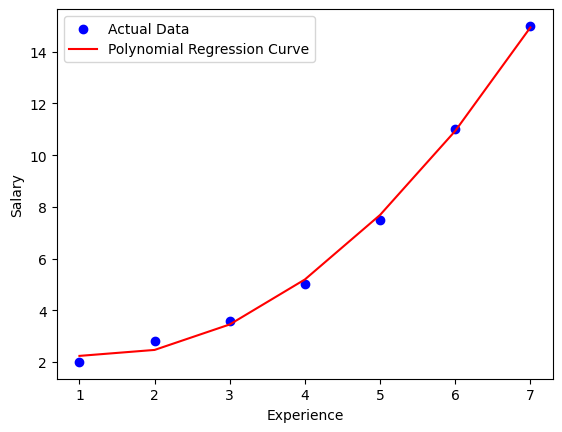

In [68]:
# Step 6: Plot Curve
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Polynomial Regression Curve')
plt.legend()
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()
